# 链式法则与雅可比矩阵

学习目标：按输出与输入排列雅可比矩阵，用它做局部线性近似和复合求导；用有限差分核对结果，并手算计算图中的反向传递与分支累加。

前置知识：偏导数、可微与局部线性近似、向量函数、矩阵乘法与转置、欧氏范数；Python 函数和数组操作。

运行环境：Python 3.12，NumPy、Matplotlib；用手算与 NumPy 展示自动微分思想，不需要安装自动微分框架。

环境准备：见 [数学基础环境与运行说明](README.md)。

工作目录：本 Notebook 所在目录；重启内核后从上到下运行。

## 1 一次输入，多个输出

设一个函数接收两个实数，返回三个特征：

$$
F(x)=\begin{bmatrix}x_1x_2\\x_1^2+x_2\\x_1^3\end{bmatrix},
\qquad x=\begin{bmatrix}x_1\\x_2\end{bmatrix}\in\mathbb R^2.
$$

这是自制的无量纲例子，定义域为整个 $\mathbb R^2$，输出属于 $\mathbb R^3$。数学向量均按列排列；代码用一维数组表示输入、输出，用二维数组表示矩阵。

先在 $x_0=(1,2)^T$ 处计算，再分别改变一个输入，观察哪些输出会受到影响。

In [1]:
import matplotlib.pyplot as plt
import numpy as np


def features(x):
    x1, x2 = x
    return np.array([x1 * x2, x1**2 + x2, x1**3])


x0 = np.array([1.0, 2.0])
print("原输入的输出：", features(x0))  # 预期为 [2. 3. 1.]。
print("改变 x₁ 后：", features(x0 + np.array([0.01, 0.0])))  # 预期约为 [2.02 3.0201 1.0303]。
print("改变 x₂ 后：", features(x0 + np.array([0.0, 0.01])))  # 预期约为 [2.01 3.01 1. ]。
# 第三个输出只依赖 x₁，因此只改变 x₂ 不会改变它。

原输入的输出： [2. 3. 1.]
改变 x₁ 后： [2.02     3.0201   1.030301]
改变 x₂ 后： [2.01 3.01 1.  ]


## 2 雅可比的行与列

对向量函数 $F:\mathbb R^n\to\mathbb R^m$，$n,m$ 是正整数，雅可比矩阵（Jacobian matrix）采用“输出在行、输入在列”的布局：

$$
J_F(x)=\left[\frac{\partial F_i}{\partial x_j}(x)\right]
\in\mathbb R^{m\times n},\qquad i=1,\ldots,m,\quad j=1,\ldots,n.
$$

$F_i$ 是第 $i$ 个输出分量，$x_j$ 是第 $j$ 个输入分量。第 $i$ 行汇总一个输出对所有输入的偏导，第 $j$ 列汇总一个输入对所有输出的影响。

逐项求导，当前例子得到

$$
J_F(x)=\begin{bmatrix}
x_2&x_1\\2x_1&1\\3x_1^2&0
\end{bmatrix},\qquad
J_F(x_0)=\begin{bmatrix}2&1\\2&1\\3&0\end{bmatrix}.
$$

In [2]:
def jacobian_features(x):
    x1, x2 = x
    return np.array([[x2, x1], [2 * x1, 1.0], [3 * x1**2, 0.0]])


JF = jacobian_features(x0)
print("雅可比：", JF)  # 预期为 [[2. 1.] [2. 1.] [3. 0.]]。
print("形状（输出数，输入数）：", JF.shape)  # 预期为 (3, 2)。
print("第一行：", JF[0, :])  # 预期为 [2. 1.]。
print("第二列：", JF[:, 1])  # 预期为 [1. 1. 0.]。
# 第三行第二列为 0，对应 F₃ 不依赖 x₂。

雅可比： [[2. 1.]
 [2. 1.]
 [3. 0.]]
形状（输出数，输入数）： (3, 2)
第一行： [2. 1.]
第二列： [1. 1. 0.]


标量函数是 $m=1$ 的特殊情况。它的雅可比是 $1\times n$ 行矩阵；本章把梯度 $\nabla q$ 定义为 $n\times1$ 列向量，因此 $J_q=(\nabla q)^T$。例如 $q(x)=x_1^2+3x_2$，有 $J_q(x)=[2x_1,3]$。

不同资料可能采用转置后的布局，比较公式前先确认约定。NumPy 一维数组转置仍是一维数组；要在代码中明确行、列形状，需要二维数组。

In [3]:
Jq = np.array([[2 * x0[0], 3.0]])
gradient_q = Jq.T
gradient_flat = np.array([2 * x0[0], 3.0])

print("标量函数的雅可比形状：", Jq.shape)  # 预期为 (1, 2)。
print("梯度列向量形状：", gradient_q.shape)  # 预期为 (2, 1)。
print("一维数组及其转置形状：", gradient_flat.shape, gradient_flat.T.shape)  # 预期为 (2,) (2,)。
# 数值一样并不意味着数学布局一样；后面的梯度计算可用一维数组承载。

标量函数的雅可比形状： (1, 2)
梯度列向量形状： (2, 1)
一维数组及其转置形状： (2,) (2,)


## 3 把非线性变化局部写成矩阵乘法

如果 $F$ 在 $x_0$ 可微，输入变化 $\Delta x\in\mathbb R^n$ 足够小时，

$$
F(x_0+\Delta x)=F(x_0)+J_F(x_0)\Delta x+R(\Delta x),
\qquad
\frac{\|R(\Delta x)\|_2}{\|\Delta x\|_2}\longrightarrow0.
$$

$R(\Delta x)\in\mathbb R^m$ 是近似误差，极限在非零 $\Delta x\to0$ 时取。雅可比把输入变化映射为输出的一阶变化；@ 在代码中完成这个矩阵乘法。

可微是使用该近似的条件，仅有各个偏导数存在还不够。各偏导在邻域内连续是常用的充分条件；本章的多项式例子满足这一条件。

In [4]:
delta_x = np.array([0.01, -0.02])
actual_change = features(x0 + delta_x) - features(x0)
linear_change = JF @ delta_x

print("实际输出变化：", actual_change)  # 预期约为 [-0.0002 0.0001 0.030301]。
print("一阶预测变化：", linear_change)  # 预期约为 [0. 0. 0.03]。
print("近似误差：", actual_change - linear_change)  # 预期约为 [-0.0002 0.0001 0.000301]。
# 输出变化有三个分量，输入变化有两个分量，乘积的形状必须相符。
print("变化的形状：", delta_x.shape, linear_change.shape)  # 预期为 (2,) (3,)。

实际输出变化： [-2.0000e-04  1.0000e-04  3.0301e-02]
一阶预测变化： [0.   0.   0.03]
近似误差： [-2.00e-04  1.00e-04  3.01e-04]
变化的形状： (2,) (3,)


当前例子的误差可以直接展开，而不依赖数值猜测。令 $\Delta x=(a,b)^T$，其中 $a,b\in\mathbb R$，在 $x_0=(1,2)^T$ 处有

$$
R(\Delta x)=\begin{bmatrix}ab\\a^2\\3a^2+a^3\end{bmatrix}.
$$

每项至少含两个小变化的因子。下面沿单位方向 $v=(0.6,-0.8)^T$ 缩小输入变化，取 $\Delta x=sv$，$s>0$ 是变化长度。检查误差相对于输入变化是否缩小。

In [5]:
direction = np.array([0.6, -0.8])
print("变化长度    误差范数      误差/变化长度")
for step in [0.1, 0.05, 0.025, 0.0125]:
    delta = step * direction
    a, b = delta
    remainder = features(x0 + delta) - features(x0) - JF @ delta
    exact_remainder = np.array([a * b, a**2, 3 * a**2 + a**3])
    error_norm = np.linalg.norm(remainder)
    # 步长从 0.1 减至 0.0125，误差范数约从 0.012544 降至 0.0001934。
    print(f"{step:.4f}      {error_norm:.6e}   {error_norm / step:.6e}")
    # 直接展开的误差与函数相减的结果应在浮点舍入尺度内一致。
    print("展开式差异：", np.linalg.norm(remainder - exact_remainder))  # 四次展开式差异均接近 0，本次均小于 1e-15。

变化长度    误差范数      误差/变化长度
0.1000      1.254401e-02   1.254401e-01
展开式差异： 1.9247028625337928e-16
0.0500      3.112319e-03   6.224638e-02
展开式差异： 2.1992933503563652e-16
0.0250      7.751243e-04   3.100497e-02
展开式差异： 6.292109207143875e-16
0.0125      1.934120e-04   1.547296e-02
展开式差异： 2.922373904953771e-16


## 4 复合函数的链式法则

现在把 $F$ 的输出送入另一个函数。一般地，令 $F:\mathbb R^n\to\mathbb R^m$、$G:\mathbb R^m\to\mathbb R^p$，其中 $p$ 是最终输出个数；记 $u=F(x)$、$H=G\circ F$，即 $H(x)=G(F(x))$。

若 $F$ 在 $x$ 可微、$G$ 在 $u=F(x)$ 可微，且复合函数在该点附近有定义，则

$$
J_H(x)=J_G(F(x))J_F(x).
$$

乘积形状为 $(p\times m)(m\times n)=p\times n$。对第 $i$ 个最终输出和第 $j$ 个原始输入，公式展开为

$$
\frac{\partial H_i}{\partial x_j}
=\sum_{k=1}^{m}
\frac{\partial G_i}{\partial u_k}(F(x))
\frac{\partial F_k}{\partial x_j}(x),
\quad i=1,\ldots,p,\quad j=1,\ldots,n.
$$

求和遍历所有中间分量 $u_k$。外层导数必须在实际中间值 $F(x)$ 处计算。

仍用前面的 $F:\mathbb R^2\to\mathbb R^3$，再定义无量纲函数

$$
G(u)=\begin{bmatrix}u_1+u_2u_3\\u_2^2-u_1\end{bmatrix},\qquad
J_G(u)=\begin{bmatrix}1&u_3&u_2\\-1&2u_2&0\end{bmatrix}.
$$

其定义域为 $\mathbb R^3$，输出属于 $\mathbb R^2$。在 $x_0$ 处，$u=(2,3,1)^T$、$H(x_0)=(5,7)^T$，链式法则给出

$$
J_H(x_0)=
\begin{bmatrix}1&1&3\\-1&6&0\end{bmatrix}
\begin{bmatrix}2&1\\2&1\\3&0\end{bmatrix}
=\begin{bmatrix}13&2\\10&5\end{bmatrix}.
$$

In [6]:
def combine(u):
    u1, u2, u3 = u
    return np.array([u1 + u2 * u3, u2**2 - u1])


def jacobian_combine(u):
    _, u2, u3 = u
    return np.array([[1.0, u3, u2], [-1.0, 2 * u2, 0.0]])


u0 = features(x0)
JG = jacobian_combine(u0)
# 外层雅可比 (2, 3) 乘内层雅可比 (3, 2)，得到复合函数的 (2, 2) 雅可比。
JH = JG @ JF
print("中间值与最终输出：", u0, combine(u0))  # 预期为 [2. 3. 1.] [5. 7.]。
print("外层、内层、复合雅可比的形状：", JG.shape, JF.shape, JH.shape)  # 预期为 (2, 3) (3, 2) (2, 2)。
print("复合雅可比：", JH)  # 预期为 [[13. 2.] [10. 5.]]。

中间值与最终输出： [2. 3. 1.] [5. 7.]
外层、内层、复合雅可比的形状： (2, 3) (3, 2) (2, 2)
复合雅可比： [[13.  2.]
 [10.  5.]]


也可以先展开复合函数，再逐项求导来核对：

$$
H_1=x_1x_2+(x_1^2+x_2)x_1^3,\qquad
H_2=(x_1^2+x_2)^2-x_1x_2.
$$

所以第一行为 $(x_2+5x_1^4+3x_1^2x_2,\ x_1+x_1^3)$，第二行为 $(4x_1(x_1^2+x_2)-x_2,\ 2(x_1^2+x_2)-x_1)$。两种推导应一致。

乘法顺序由变化传递方向决定：先作用 $J_F$，再作用 $J_G$。矩阵相乘能执行只是形状相容，不代表表达了目标函数的导数。

In [7]:
x1, x2 = x0
JH_expanded = np.array(
    [
        [x2 + 5 * x1**4 + 3 * x1**2 * x2, x1 + x1**3],
        [4 * x1 * (x1**2 + x2) - x2, 2 * (x1**2 + x2) - x1],
    ]
)

print("两种推导之差：", JH - JH_expanded)  # 预期为 [[0. 0.] [0. 0.]]。
print("正确顺序的形状：", (JG @ JF).shape)  # 预期为 (2, 2)。
print("反过来相乘的形状：", (JF @ JG).shape)  # 预期为 (3, 3)。
# 反向乘积能计算，却是 3×3；目标 H 需要 2×2 的雅可比。

两种推导之差： [[0. 0.]
 [0. 0.]]
正确顺序的形状： (2, 2)
反过来相乘的形状： (3, 3)


## 5 用有限差分核对每一列

有限差分通过附近函数值估计导数，可用来检查手推公式和代码。令 $e_j\in\mathbb R^n$ 为第 $j$ 个标准基向量，即第 $j$ 个分量为 $1$，其余为 $0$。中心差分给出第 $j$ 列的近似：

$$
J_H(x)_{:,j}\approx\frac{H(x+h e_j)-H(x-h e_j)}{2h},\qquad h>0.
$$

记号 $[:,j]$ 表示整列。两个扰动点都必须在定义域内，而且函数应在核对点附近满足相应可微条件。先只检查第一列。

In [8]:
def composed(x):
    return combine(features(x))


h = 1e-5
first_basis = np.array([1.0, 0.0])
first_column_fd = (composed(x0 + h * first_basis) - composed(x0 - h * first_basis)) / (
    2 * h
)

print("第一列的差分近似：", first_column_fd)  # 预期为 [13. 10.]。
print("第一列的解析值：", JH[:, 0])  # 预期为 [13. 10.]。
print("最大分量误差：", np.max(np.abs(first_column_fd - JH[:, 0])))  # 本次数值约为 1.2e-09。
# 该列同时核对两个最终输出对 x₁ 的偏导。

第一列的差分近似： [13. 10.]
第一列的解析值： [13. 10.]
最大分量误差： 1.239795821561529e-09


对每个输入依次重复，就得到完整雅可比。下面的小函数只处理一维实数输入、固定长度的一维输出，假定传入的步长为正且扰动点有效；np.eye 生成标准基，np.column_stack 把各次差分作为列排列。

In [9]:
def central_jacobian(function, x, step):
    columns = []
    # 依次扰动一个输入坐标；每次返回的输出差组成雅可比的一列。
    for basis in np.eye(x.size):
        plus = function(x + step * basis)
        minus = function(x - step * basis)
        columns.append((plus - minus) / (2 * step))
    # 按列拼接，保持“输出数 × 输入数”的布局。
    return np.column_stack(columns)


JH_fd = central_jacobian(composed, x0, 1e-5)
print("差分雅可比：", JH_fd)  # 预期为 [[13. 2.] [10. 5.]]。
print("形状：", JH_fd.shape)  # 预期为 (2, 2)。
print("与解析值的最大分量误差：", np.max(np.abs(JH_fd - JH)))  # 本次数值约为 1.2e-09。
# 当前输入与导数量级适中，1e-7 的绝对误差尺度可用于这次核对。
print("是否小于本次核对尺度：", np.max(np.abs(JH_fd - JH)) < 1e-7)  # 预期为 True。

差分雅可比： [[13.  2.]
 [10.  5.]]
形状： (2, 2)
与解析值的最大分量误差： 1.239795821561529e-09
是否小于本次核对尺度： True


步长越小不一定越准确。较大的步长混入非线性变化；很小的步长则使相近浮点数相减，舍入误差可能被除以 $2h$ 放大。应试验多个步长，并结合输入、导数量级判断。

下面仍核对同一点的同一个多项式。误差用所有矩阵元素的最大绝对差衡量，而不是把某次差分结果当作精确真值。

In [10]:
steps = 10.0 ** (-np.arange(1, 13))
errors = []
for step in steps:
    approximation = central_jacobian(composed, x0, step)
    error = np.max(np.abs(approximation - JH))
    errors.append(error)
    print(f"h={step:.0e}，最大分量误差={error:.6e}")  # 误差先减后增；本次 h=1e-6 时约 7e-10，h=1e-12 时回升至约 8.9e-4。
# 观察误差先下降、随后受浮点运算影响回升的区间。

h=1e-01，最大分量误差=1.201000e-01
h=1e-02，最大分量误差=1.200010e-03
h=1e-03，最大分量误差=1.200000e-05
h=1e-04，最大分量误差=1.199981e-07
h=1e-05，最大分量误差=1.239796e-09
h=1e-06，最大分量误差=6.988898e-10
h=1e-07，最大分量误差=5.838672e-09
h=1e-08，最大分量误差=6.077471e-08
h=1e-09，最大分量误差=8.274037e-07
h=1e-10，最大分量误差=1.075625e-06
h=1e-11，最大分量误差=1.075625e-06
h=1e-12，最大分量误差=8.890058e-04


比较不同差分步长下的雅可比误差，观察本例误差随步长的变化。这张图不提供适用于所有函数的最佳步长。

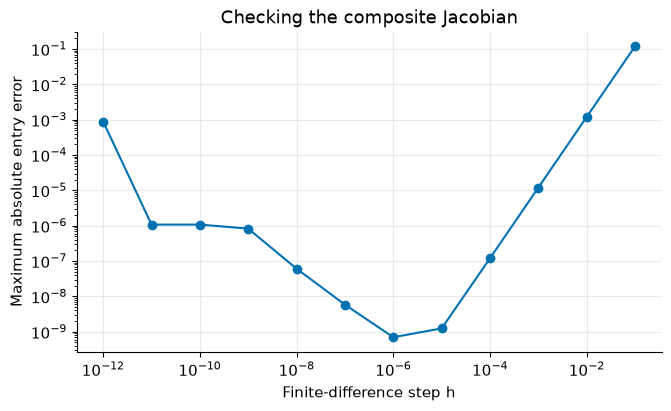

In [11]:
# 横轴为差分步长，纵轴为雅可比元素的最大绝对误差。
# 两轴均采用对数刻度，便于比较数量级。
plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 11,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
    }
)
# 误差已在前一单元计算；这里仅设置绘图外观并显示误差曲线。
blue = "#0072B2"
fig, ax = plt.subplots(figsize=(6.6, 4), layout="constrained")
ax.loglog(steps, errors, "o-", color=blue)
ax.set(
    xlabel="Finite-difference step h",
    ylabel="Maximum absolute entry error",
    title="Checking the composite Jacobian",
)
ax.grid(which="major", alpha=0.25)
# 预期误差随 h 缩小先降后升；本次最低点在约 1e-6 附近。
plt.show()

## 6 用计算图记录共享中间量

复合计算也可以拆成只含简单运算的节点。考虑无量纲标量输入 $x,y\in\mathbb R$，定义

$$u=xy,\qquad v=u^2,\qquad w=3u,\qquad L=v+w.$$

计算图的箭头表示数据依赖。$u$ 同时送入两个分支，所以不能只计算其中一条路径对输入的影响。先按依赖顺序从输入算到输出，并保留反向求导需要的中间值。

In [12]:
x, y = 2.0, 3.0
u = x * y
v = u**2
w = 3.0 * u
loss = v + w

print("x、y：", x, y)  # 预期为 2 3。
print("u、v、w、L：", u, v, w, loss)  # 预期为 6 36 18 54。
# u 只计算一次，随后被平方和乘以 3 两条分支共同使用。

x、y： 2.0 3.0
u、v、w、L： 6.0 36.0 18.0 54.0


下图是计算依赖示意图，节点中的数值来自刚才的计算。蓝色节点 $u$ 向外分成两条路径，最后在 $L$ 相加；反向求导时，两条路径的贡献会回到 $u$。

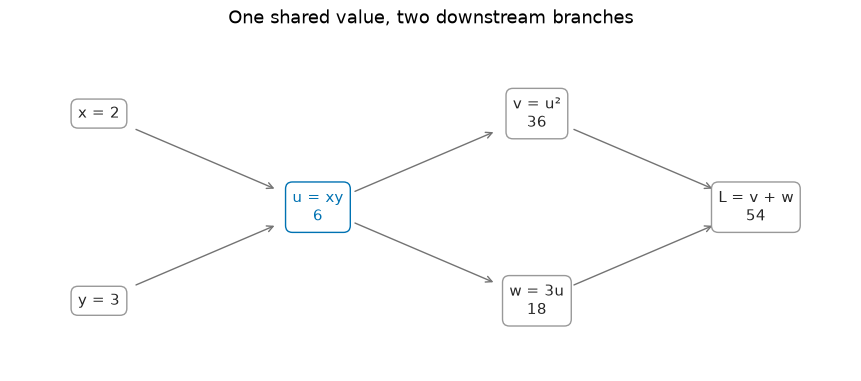

In [13]:
# 位置字典保存绘图坐标，标签字典保存实际计算值，二者含义不同。
node_positions = {
    "x": (0, 0.8),
    "y": (0, -0.8),
    "u": (1.6, 0),
    "v": (3.2, 0.8),
    "w": (3.2, -0.8),
    "L": (4.8, 0),
}
node_labels = {
    "x": f"x = {x:g}",
    "y": f"y = {y:g}",
    "u": f"u = xy\n{u:g}",
    "v": f"v = u²\n{v:g}",
    "w": f"w = 3u\n{w:g}",
    "L": f"L = v + w\n{loss:g}",
}
fig, ax = plt.subplots(figsize=(8.5, 3.7), layout="constrained")
# 每条边按“输入节点 → 使用它的节点”记录，展示正向依赖关系。
edges = [("x", "u"), ("y", "u"), ("u", "v"), ("u", "w"), ("v", "L"), ("w", "L")]
# 先画箭头；shrinkA/B 留出文字框空间，避免箭头穿过标签。
for start, end in edges:
    ax.annotate(
        "",
        xy=node_positions[end],
        xytext=node_positions[start],
        arrowprops={
            "arrowstyle": "->",
            "color": "0.45",
            "shrinkA": 29,
            "shrinkB": 34,
        },
    )
# 再覆盖节点文字框，并突出被两个分支共用的 u。
for name, position in node_positions.items():
    ax.text(
        *position,
        node_labels[name],
        ha="center",
        va="center",
        color=blue if name == "u" else "0.15",
        bbox={
            "boxstyle": "round,pad=0.45",
            "facecolor": "white",
            "edgecolor": blue if name == "u" else "0.6",
        },
    )
ax.set(
    xlim=(-0.65, 5.5),
    ylim=(-1.4, 1.5),
    title="One shared value, two downstream branches",
)
ax.axis("off")
# 预期 u=6 分成 v=36、w=18 两条分支，最后汇合为 L=54。
plt.show()

## 7 反向传递时为什么要累加

对任一标量节点 $z$，用 $\bar z=\partial L/\partial z$ 表示最终输出对该节点的导数。横线是本章的反向导数记号，不表示平均值。局部导数只描述相邻节点之间的一步；乘上来自下游的导数，才得到该路径对 $L$ 的贡献。

从 $\bar L=1$ 开始。因为 $L=v+w$，有 $\bar v=1$、$\bar w=1$。共享节点 $u$ 接收两份贡献：

$$
\bar u
=\bar v\frac{\partial v}{\partial u}
+\bar w\frac{\partial w}{\partial u}
=\bar v(2u)+\bar w(3).
$$

再经过 $u=xy$，得到 $\bar x=\bar u\,y$、$\bar y=\bar u\,x$。在本例中，$\bar u=12+3=15$，因此 $\bar x=45$、$\bar y=30$。

In [14]:
bar_loss = 1.0
bar_v = bar_loss
bar_w = bar_loss
bar_u = 0.0
# u 同时通向平方与线性分支，先累计平方分支贡献。
bar_u += bar_v * (2 * u)
# 继续累加线性分支贡献，再把总贡献传回 x、y。
bar_u += bar_w * 3.0
bar_x = bar_u * y
bar_y = bar_u * x

print("来自平方分支、线性分支的贡献：", bar_v * 2 * u, bar_w * 3.0)  # 预期为 12 3。
print("汇总后的 u 导数：", bar_u)  # 预期为 15。
print("输入梯度：", np.array([bar_x, bar_y]))  # 预期为 [45. 30.]。
# += 保留已有贡献；若第二条分支覆盖第一条，输入梯度就会漏项。

来自平方分支、线性分支的贡献： 12.0 3.0
汇总后的 u 导数： 15.0
输入梯度： [45. 30.]


反向累加是多元链式法则的求和，不是对多条路径取平均。把原式展开为 $L=x^2y^2+3xy$，直接求导得到

$$
\nabla L=\begin{bmatrix}2xy^2+3y\\2x^2y+3x\end{bmatrix}.
$$

下面同时比较展开式、反向累加和中心差分。再故意只保留 $w$ 分支，观察漏掉的贡献。

In [15]:
def shared_loss(inputs):
    shared = inputs[0] * inputs[1]
    return shared**2 + 3.0 * shared


graph_input = np.array([x, y])
gradient_reverse = np.array([bar_x, bar_y])
gradient_expanded = np.array([2 * x * y**2 + 3 * y, 2 * x**2 * y + 3 * x])
# 标量损失包装成一个输出，因此差分雅可比只有一行；[0] 取出梯度。
gradient_fd = central_jacobian(
    lambda inputs: np.array([shared_loss(inputs)]), graph_input, 1e-5
)[0]

print("反向累加：", gradient_reverse)  # 预期为 [45. 30.]。
print("展开式求导：", gradient_expanded)  # 预期为 [45. 30.]。
print("差分核对：", gradient_fd)  # 预期为 [45. 30.]。
print("故意遗漏平方分支：", 3.0 * np.array([y, x]))  # 预期为 [9. 6.]。
# 最后一行是错误做法的对照，不是另一种有效的梯度定义。

反向累加： [45. 30.]
展开式求导： [45. 30.]
差分核对： [45. 30.]
故意遗漏平方分支： [9. 6.]


自动微分（automatic differentiation，AD）的核心是为基本运算准备局部导数规则，再按程序的依赖关系组合它们。反向模式从标量输出往回传播，在共享节点累加贡献；一般需要保留或重新计算求导所需的前向值。

上面是手写的一次反向过程，用来展示原理，还不是会自动记录任意 Python 程序的微分系统。它没有使用差分步长，也没有先把整个表达式符号展开；浮点计算仍然可能产生舍入误差。

也可以从输入方向往前传递变化。设输入方向 $d=(d_x,d_y)^T$，用圆点表示沿该方向的导数，则 $\dot u=yd_x+xd_y$、$\dot v=2u\dot u$、$\dot w=3\dot u$、$\dot L=\dot v+\dot w$。

In [16]:
input_direction = np.array([0.6, -0.8])
dot_u = y * input_direction[0] + x * input_direction[1]
dot_v = 2 * u * dot_u
dot_w = 3.0 * dot_u
dot_loss = dot_v + dot_w

print("前向传递的方向导数：", dot_loss)  # 预期约为 3。
print("反向梯度与方向的内积：", gradient_reverse @ input_direction)  # 预期约为 3。
# 两种组织方式应用的是同一个链式法则，这里都得到 3。

前向传递的方向导数： 2.999999999999996
反向梯度与方向的内积： 3.0


## 8 综合应用：从向量输出回到标量误差

复用 $H=G\circ F:\mathbb R^2\to\mathbb R^2$。给定无量纲目标 $c=(4,5)^T$，定义残差 $r=H(x)-c\in\mathbb R^2$ 和标量平方误差

$$\ell(x)=\tfrac12r^Tr=\tfrac12\sum_{i=1}^{2}(H_i(x)-c_i)^2.$$

把 $H_i$ 暂时看作独立变量，对每一项求导得到 $\partial\ell/\partial H_i=H_i-c_i=r_i$。因此按列梯度约定，

$$
\nabla_x\ell
=J_H(x)^Tr
=J_F(x)^T\bigl(J_G(F(x))^Tr\bigr).
$$

反向传播依次把二维输出的导数变成三维中间量的导数，再回到二维输入。这个转置乘积就是反向模式所用的向量—雅可比乘积的列向量写法。

In [17]:
target = np.array([4.0, 5.0])
output = composed(x0)
residual = output - target
objective = 0.5 * (residual @ residual)
bar_output = residual
bar_middle = JG.T @ bar_output
bar_input = JF.T @ bar_middle

print("输出、残差、平方误差：", output, residual, objective)  # 预期约为 [5. 7.] [1. 2.] 2.5。
# 预期为 (2,) (3,) (2,)。
print(
    "输出→中间量→输入的导数形状：",
    bar_output.shape,
    bar_middle.shape,
    bar_input.shape,
)
print("分步反向得到的输入梯度：", bar_input)  # 预期为 [33. 12.]。
print("先构造复合雅可比再计算：", JH.T @ residual)  # 预期为 [33. 12.]。
# 这组自制输入下，误差为 2.5，梯度为 (33, 12)。

输出、残差、平方误差： [5. 7.] [1. 2.] 2.5
输出→中间量→输入的导数形状： (2,) (3,) (2,)
分步反向得到的输入梯度： [33. 12.]
先构造复合雅可比再计算： [33. 12.]


最后用两种检查观察这个梯度。逐坐标中心差分核对所有分量；沿一个指定方向的差分核对 $d^T\nabla\ell$，只需要该方向两侧的函数值。

方向检查只覆盖被选中的方向，可能漏掉与该方向正交的错误。即使有限次检查都很接近，也只是当前输入的数值证据，不能代替链式法则的条件与推导。

In [18]:
def objective_value(inputs):
    difference = composed(inputs) - target
    return 0.5 * (difference @ difference)


# 逐坐标差分检查整个梯度，方向差分则检查它与指定方向的内积。
gradient_check = central_jacobian(
    lambda inputs: np.array([objective_value(inputs)]), x0, 1e-5
)[0]
directional_check = (
    objective_value(x0 + 1e-5 * direction) - objective_value(x0 - 1e-5 * direction)
) / (2e-5)

print("逐坐标核对的最大误差：", np.max(np.abs(gradient_check - bar_input)))  # 本次数值约为 3.3e-08。
print("方向差分与梯度内积：", directional_check, bar_input @ direction)  # 预期约为 10.2 10.2。
# 多项式复合后的曲率更大，应检查步长与误差，不沿用所有例子的统一容差。

逐坐标核对的最大误差： 3.2878951117254474e-08
方向差分与梯度内积： 10.200000003224297 10.2


## 9 导数存在与数值结果是两件事

局部求导规则也有成立条件。以 $a(t)=|t|$ 为例，实数输入 $t=0$ 处的右侧变化率为 $1$，左侧变化率为 $-1$，所以普通导数不存在。中心差分却对任何正步长都给出 $0$。

因此，数值程序返回一个值，不足以证明函数在该点可微。自动微分也需要各个基本运算的导数规则；遇到不可微点，应区分工具采用的规则与普通导数的存在性。

In [19]:
for step in [1e-2, 1e-4, 1e-6]:
    right_rate = (abs(step) - abs(0.0)) / step
    left_rate = (abs(0.0) - abs(-step)) / step
    centered_rate = (abs(step) - abs(-step)) / (2 * step)
    # 每组左侧为 -1、右侧为 1、中心差分为 0。
    print(
        f"h={step:.0e}：左侧={left_rate:.1f}，右侧={right_rate:.1f}，"
        f"中心差分={centered_rate:.1f}"
    )
# 中心差分的稳定结果掩盖了两侧导数不一致，不能把 0 当作此处的导数。

h=1e-02：左侧=-1.0，右侧=1.0，中心差分=0.0
h=1e-04：左侧=-1.0，右侧=1.0，中心差分=0.0
h=1e-06：左侧=-1.0，右侧=1.0，中心差分=0.0


## 本章小结

雅可比按“输出行、输入列”排列，把输入的小变化映射为输出的一阶变化。复合函数按 $J_G(F(x))J_F(x)$ 求导，既要核对形状，也要核对求值位置与可微条件。

计算图把复合求导分成局部规则。反向传播从输出累积导数，共享节点收到的各分支贡献相加；对标量目标，转置雅可比把下游梯度传回输入。有限差分可以核对实现，但受步长和可微性限制。

理解自查：如果一段代码的矩阵乘法能运行、差分误差也很小，还需要检查哪些条件，才能认为它表达了目标函数的导数？

## 练习

（1）设无量纲函数 $P(x_1,x_2)=(x_1+x_2^2,\ x_1x_2,\ x_2^3)^T$。先写出雅可比的形状和每个元素，再在 $(2,-1)^T$ 处计算。选择一个小输入变化，比较实际输出变化和雅可比预测，并用中心差分逐列核对。

In [20]:
exercise_point = np.array([2.0, -1.0])
exercise_delta = np.array([0.01, 0.02])

# 在这里定义 P 和手算的雅可比。
# 先检查形状，再比较局部变化及中心差分；解释误差所用尺度。

（2）复用正文中的 $F$，改用标量外层函数 $S(u)=2u_1-u_2+u_3^2$。写出 $J_S$ 的形状，在 $x_0=(1,2)^T$ 处求 $J_{S\circ F}$ 和列梯度。说明为什么外层导数必须在 $F(x_0)$ 处计算，以及一维数组转置为什么不能替代数学布局说明。

In [21]:
exercise_input = np.array([1.0, 2.0])
exercise_middle = features(exercise_input)

# 写出 S、J_S，按形状正确的顺序与 J_F 相乘。
# 使用中心差分核对标量复合函数的各个输入偏导。

（3）把共享节点例子的输出改为 $L=u^2+3u+x$，仍取 $u=xy$、$x=2$、$y=3$。新增的直接路径对哪个输入增加贡献？先画出依赖关系或列出路径，再按反向顺序累加，最后用展开式和差分核对。所有变量均无量纲。

In [22]:
exercise_x, exercise_y = 2.0, 3.0
exercise_u = exercise_x * exercise_y

# 先计算输出，反向求导时同时保留经过 u 和直接到 x 的贡献。
# 不要让新路径覆盖已经计算出的导数。

（4）改变函数的光滑条件，令 $B(x_1,x_2)=(|x_1|,x_2)^T$。在 $(0,1)^T$ 处用中心差分计算矩阵，再单独检查第一输出对第一输入的左右变化率。解释这个差分矩阵为什么不能作为该点存在雅可比线性近似的证据；再到 $(1,1)^T$ 处重复比较。

In [23]:
exercise_boundary = np.array([0.0, 1.0])
exercise_smooth = np.array([1.0, 1.0])

# 定义 B，比较中心差分与左右变化率。
# 写出两个输入点的可微条件差异，并据此解释计算结果。

## 练习提示与解析

以下对应练习（3）。先独立作答，卡住时依次查看提示，完成后再对照解析。

提示 1：先求 L 对共享节点 u 的导数，再沿两条输入路径传回。

提示 2：x 还直接进入输出；这条路径的贡献必须相加。

### 练习（3）参考解析

$u=6$，$L=6^2+3\times6+2=56$。输出对 u 的导数为 $2u+3=15$，因此

$$\frac{\partial L}{\partial x}=15y+1=46,\qquad
\frac{\partial L}{\partial y}=15x=30.$$

展开 $L=x^2y^2+3xy+x$ 后逐项求导得到相同结果。遗漏直接到 x 的路径会把第一项错算成 45；用后写的 1 覆盖已有贡献也不对，反向传播在分支汇合处做的是累加。

## 参考与引用来源

| 网站 | 本章参考内容与定位 |
| --- | --- |
| MIT OpenCourseWare | 18.024 [Course Notes, Chapter C](https://ocw.mit.edu/courses/18-024-multivariable-calculus-with-theory-spring-2011/cdf8e8d3cd13b6b8035d4bd7812bcd97_MIT18_024s11_ChCnotes.pdf)，PDF 第 1–3 页 Derivatives of vector functions、Theorem 1：输出行布局、可微与线性近似余项；第 4–9 页 The general chain rule、Theorems 3–4：逐项求和、乘积顺序及可微条件。 |
| Explained.ai | Terence Parr、Jeremy Howard，[The Matrix Calculus You Need For Deep Learning](https://explained.ai/matrix-calculus/)，Generalization of the Jacobian、The Chain Rules / Vector chain rule：输入输出布局与复合求导；本章另外明确采用列梯度约定。 |
| JAX 文档 | [Forward- and reverse-mode autodiff](https://docs.jax.dev/en/latest/jacobian-vector-products.html)，JVPs in math、JVPs in JAX code、VJPs in math：局部规则、前向方向传递与反向转置乘积；[Automatic differentiation](https://docs.jax.dev/en/latest/automatic-differentiation.html)，Checking against numerical differences：逐参数及方向差分核对。仅参考原理，本章不安装或调用 JAX。 |
| Stanford CS231n | [Backpropagation](https://cs231n.github.io/optimization-2/)，Compound expressions, chain rule, backpropagation；Backprop in practice: Staged computation；Gradients add up at forks：计算图、前向中间值、局部导数与共享节点累加。 |
| SciPy | [scipy.differentiate.jacobian](https://docs.scipy.org/doc/scipy/reference/generated/scipy.differentiate.jacobian.html)，step_factor、step_direction、Notes：有限差分、步长消减误差与定义域边界；本章用 NumPy 手写中心差分，没有调用该接口。 |
| OpenStax | [Calculus Volume 1, §3.2](https://openstax.org/books/calculus-volume-1/pages/3-2-the-derivative-as-a-function)，Derivatives and Continuity、Figure 3.14：绝对值函数在零点的左右变化率与不可微性。 |
| NumPy | 2.5 文档：[eye](https://numpy.org/doc/stable/reference/generated/numpy.eye.html)，Parameters、Returns：标准基生成；[column_stack](https://numpy.org/doc/stable/reference/generated/numpy.column_stack.html)，输入列堆叠与二维输出；[transpose](https://numpy.org/doc/stable/reference/generated/numpy.transpose.html)，一维数组的转置行为。 |
| Matplotlib | [Axes.annotate](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.annotate.html)，xy、xytext、arrowprops 中的 shrinkA/shrinkB：计算图依赖箭头；[Axes.loglog](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.loglog.html)，双轴对数刻度。 |